In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import joblib
import yfinance as yf
import matplotlib.pyplot as plt
ticker='NFLX'
stock=yf.Ticker(ticker)
netflix_df=stock.history(start='2000-01-01',end='2025-12-31')
netflix_df

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2002-05-23 00:00:00-04:00,0.115643,0.124286,0.114571,0.119643,1047900000,0.0,0.0
2002-05-24 00:00:00-04:00,0.121429,0.122500,0.119714,0.121000,111048000,0.0,0.0
2002-05-28 00:00:00-04:00,0.121357,0.123214,0.115714,0.115714,66094000,0.0,0.0
2002-05-29 00:00:00-04:00,0.116429,0.116429,0.108571,0.110357,67578000,0.0,0.0
2002-05-30 00:00:00-04:00,0.110786,0.110786,0.107143,0.107143,101542000,0.0,0.0
...,...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,93.400002,93.809998,91.330002,93.500000,25896200,0.0,0.0
2025-12-24 00:00:00-05:00,93.110001,93.680000,92.669998,93.639999,12427900,0.0,0.0
2025-12-26 00:00:00-05:00,93.480003,94.690002,93.269997,94.470001,22068300,0.0,0.0


In [2]:
timesteps=netflix_df.index.to_numpy()
prices=netflix_df['Close'].to_numpy()
timesteps,prices

(array([Timestamp('2002-05-23 00:00:00-0400', tz='America/New_York'),
        Timestamp('2002-05-24 00:00:00-0400', tz='America/New_York'),
        Timestamp('2002-05-28 00:00:00-0400', tz='America/New_York'), ...,
        Timestamp('2025-12-26 00:00:00-0500', tz='America/New_York'),
        Timestamp('2025-12-29 00:00:00-0500', tz='America/New_York'),
        Timestamp('2025-12-30 00:00:00-0500', tz='America/New_York')],
       shape=(5940,), dtype=object),
 array([ 0.119643  ,  0.121     ,  0.115714  , ..., 94.47000122,
        94.15000153, 93.77999878], shape=(5940,)))

In [3]:
split_1=int(0.8*len(prices))
x1,y1=timesteps[:split_1],prices[:split_1] # splitting raw prices before returns to prevent data leakage
x2,y2=timesteps[split_1:],prices[split_1:]

In [4]:
x1_returns,x2_returns=x1[1:],x2[1:]  #x1,x2: timsteps for returns 
y1_returns,y2_returns=np.diff(y1),np.diff(y2)
y1_returns,y2_returns

(array([ 0.001357  , -0.005286  , -0.005357  , ...,  0.38599777,
         0.2460022 ,  0.75899887], shape=(4751,)),
 array([-0.25299835,  0.09500122, -1.3710022 , ...,  0.83000183,
        -0.31999969, -0.37000275], shape=(1187,)))

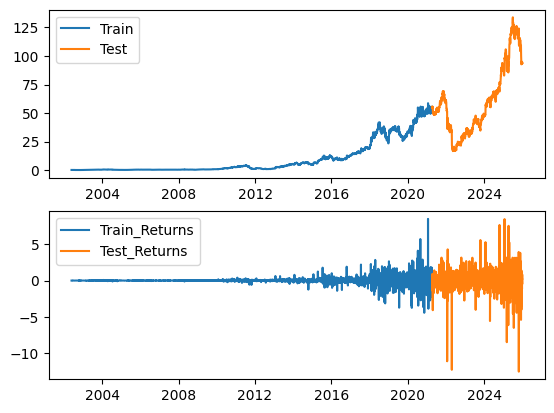

In [5]:
fig,ax=plt.subplots(2,1)
ax[0].plot(x1,y1)
ax[0].plot(x2,y2)
ax[0].legend(['Train','Test'])
ax[1].plot(x1_returns,y1_returns)
ax[1].plot(x2_returns,y2_returns)
ax[1].legend(['Train_Returns','Test_Returns'])

In [6]:
def mean_absolute_scaled_error(y_true,y_pred):
    y_true=tf.convert_to_tensor(y_true)
    y_pred=tf.convert_to_tensor(y_pred)
    mae=tf.reduce_mean(tf.abs(y_true-y_pred))
    mae_no_season=tf.reduce_mean(tf.abs(y_true[1:]-y_true[:-1]))
    mase=mae/mae_no_season
    return mase

In [7]:
def evaluate_metrics(y_true,y_pred):
    y_true=tf.cast(y_true,dtype=tf.float32)
    y_pred=tf.cast(y_pred,dtype=tf.float32)
    mae=tf.keras.metrics.mae(y_true,y_pred)
    rmse=tf.sqrt(tf.keras.metrics.mse(y_true,y_pred))
    mape=tf.keras.metrics.mape(y_true,y_pred)
    mase=mean_absolute_scaled_error(y_true,y_pred)
    return {'MAE':mae.numpy(),'RMSE':rmse.numpy(),'MAPE':mape.numpy(),'MASE':mase.numpy()}

In [8]:
naive_forecast=y2_returns[:-1]
y2_returns[-10:],naive_forecast[-10:]

(array([ 0.80000305,  0.22000122, -0.79000092,  0.38999939, -1.15999603,
         0.26999664,  0.13999939,  0.83000183, -0.31999969, -0.37000275]),
 array([-1.4200058 ,  0.80000305,  0.22000122, -0.79000092,  0.38999939,
        -1.15999603,  0.26999664,  0.13999939,  0.83000183, -0.31999969]))

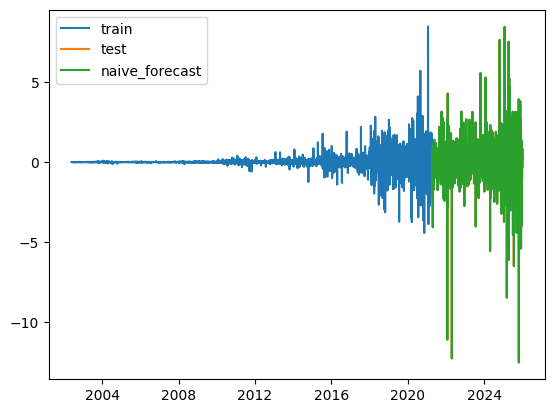

In [9]:
fig,ax=plt.subplots()
ax.plot(x1_returns,y1_returns)
ax.plot(x2_returns,y2_returns)
ax.plot(x2_returns[1:],naive_forecast)
ax.legend(['train','test','naive_forecast'])

In [10]:
naive_results=evaluate_metrics(y_true=y2_returns[1:],y_pred=naive_forecast)
naive_results

{'MAE': np.float32(1.3567512),
 'RMSE': np.float32(2.0483763),
 'MAPE': np.float32(414440.72),
 'MASE': np.float32(0.9993729)}

In [11]:
def get_labelled_window(x,horizon):
    return x[:,:-horizon],x[:,-horizon:]

In [12]:
def make_windows(x,window,horizon):
    window_step=tf.expand_dims(np.arange(window+horizon),axis=0)
    window_indices=window_step+np.expand_dims(np.arange(len(x)-(horizon+window-1)),axis=0).T
    window_array=x[window_indices]
    window,label=get_labelled_window(window_array,horizon=horizon)
    return window,label

In [13]:
train_7_windows,train_7_labels=make_windows(y1_returns,horizon=1,window=7)
test_7_windows,test_7_labels=make_windows(y2_returns,horizon=1,window=7)
train_10_windows,train_10_labels=make_windows(y1_returns,horizon=1,window=10)
test_10_windows,test_10_labels=make_windows(y2_returns,horizon=1,window=10)
train_14_windows,train_14_labels=make_windows(y1_returns,horizon=1,window=14)
test_14_windows,test_14_labels=make_windows(y2_returns,horizon=1,window=14)
train_7_windows.shape,train_7_labels.shape

((4744, 7), (4744, 1))

In [14]:
from tensorflow.keras.layers import Dense,LSTM,Input,Lambda,GRU
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import mae
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau

In [15]:
def model_preds_uni(model,input_data):
    preds=model.predict(input_data)
    return tf.squeeze(preds)

In [16]:
tf.random.set_seed(42)
model_1=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])
model_1.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_1.fit(train_7_windows,train_7_labels,batch_size=64,epochs=100,validation_data=(test_7_windows,test_7_labels),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1796 - mae: 0.1796 - val_loss: 0.9613 - val_mae: 0.9613 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1767 - mae: 0.1767 - val_loss: 0.9627 - val_mae: 0.9627 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1756 - mae: 0.1756 - val_loss: 0.9624 - val_mae: 0.9624 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1749 - mae: 0.1749 - val_loss: 0.9652 - val_mae: 0.9652 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1741 - mae: 0.1741 - val_loss: 0.9637 - val_mae: 0.9637 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1738 - mae: 0.1738 - val_loss: 0.9661 - val_mae: 0.9661 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1733 - mae: 0.1733 - val_loss: 0.9664 - val_mae: 0.9664 - learning_rate: 0.0010
Epoch 8/100
7

In [17]:
model_1_preds=model_preds_uni(model_1,test_7_windows)
model_1_results=evaluate_metrics(y_true=tf.squeeze(test_7_labels),y_pred=model_1_preds)
model_1_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'MAE': np.float32(0.9613182),
 'RMSE': np.float32(1.4746687),
 'MAPE': np.float32(87875.016),
 'MASE': np.float32(0.7093027)}

In [18]:
tf.random.set_seed(42)
model_2=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])
model_2.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_2.fit(train_10_windows,train_10_labels,batch_size=64,epochs=100,validation_data=(test_10_windows,test_10_labels),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1816 - mae: 0.1816 - val_loss: 0.9639 - val_mae: 0.9639 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1768 - mae: 0.1768 - val_loss: 0.9664 - val_mae: 0.9664 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1753 - mae: 0.1753 - val_loss: 0.9672 - val_mae: 0.9672 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1739 - mae: 0.1739 - val_loss: 0.9698 - val_mae: 0.9698 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1729 - mae: 0.1729 - val_loss: 0.9728 - val_mae: 0.9728 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1721 - mae: 0.1721 - val_loss: 0.9711 - val_mae: 0.9711 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1714 - mae: 0.1714 - val_loss: 0.9785 - val_mae: 0.9785 - learning_rate: 0.0010
Epoch 8/100
7

In [19]:
model_2_preds=model_preds_uni(model_2,test_10_windows)
model_2_results=evaluate_metrics(y_true=tf.squeeze(test_10_labels),y_pred=model_2_preds)
model_2_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'MAE': np.float32(0.9639479),
 'RMSE': np.float32(1.4835999),
 'MAPE': np.float32(60678.777),
 'MASE': np.float32(0.7117334)}

In [20]:
tf.random.set_seed(42)
model_3=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])
model_3.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_3.fit(train_14_windows,train_14_labels,batch_size=64,epochs=100,validation_data=(test_14_windows,test_14_labels),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1877 - mae: 0.1877 - val_loss: 0.9750 - val_mae: 0.9750 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1763 - mae: 0.1763 - val_loss: 0.9731 - val_mae: 0.9731 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1740 - mae: 0.1740 - val_loss: 0.9780 - val_mae: 0.9780 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1718 - mae: 0.1718 - val_loss: 0.9837 - val_mae: 0.9837 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1705 - mae: 0.1705 - val_loss: 0.9862 - val_mae: 0.9862 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1694 - mae: 0.1694 - val_loss: 0.9848 - val_mae: 0.9848 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1683 - mae: 0.1683 - val_loss: 0.9835 - val_mae: 0.9835 - learning_rate: 0.0010
Epoch 8/100
7

In [21]:
model_3_preds=model_preds_uni(model_3,test_14_windows)
model_3_results=evaluate_metrics(y_true=tf.squeeze(test_14_labels),y_pred=model_3_preds)
model_3_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 981us/step


{'MAE': np.float32(0.9731088),
 'RMSE': np.float32(1.4845577),
 'MAPE': np.float32(49356.3),
 'MASE': np.float32(0.7168961)}

In [22]:
tf.random.set_seed(42)
model_uni_lstm_1=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    LSTM(32,activation='tanh',recurrent_dropout=0.2,return_sequences=True),
    LSTM(32,activation='tanh',recurrent_dropout=0.2),
    Dense(1)
])

model_uni_lstm_1.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_uni_lstm_1.fit(train_7_windows,train_7_labels,batch_size=64,epochs=100,validation_data=(test_7_windows,test_7_labels),callbacks=[reducelr,early_stop])

Epoch 1/100

75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1778 - mae: 0.1778 - val_loss: 0.9428 - val_mae: 0.9428 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9435 - val_mae: 0.9435 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9437 - val_mae: 0.9437 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9441 - val_mae: 0.9441 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9438 - val_mae: 0.9438 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9448 - val_mae: 0.9448 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9446 - val_mae: 0.9446 - learning_rate: 0.0010
Epoch 8/100


In [23]:
model_uni_lstm_1_preds=model_preds_uni(model_uni_lstm_1,test_7_windows)
model_uni_lstm_1_results=evaluate_metrics(y_true=tf.squeeze(test_7_labels),y_pred=model_uni_lstm_1_preds)
model_uni_lstm_1_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


{'MAE': np.float32(0.94278914),
 'RMSE': np.float32(1.4624207),
 'MAPE': np.float32(11874.24),
 'MASE': np.float32(0.69563115)}

In [24]:
tf.random.set_seed(42)
model_uni_lstm_2=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    LSTM(32,activation='relu',recurrent_dropout=0.2,return_sequences=True),
    LSTM(32,activation='relu',recurrent_dropout=0.2),
    Dense(1)
])

model_uni_lstm_2.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_uni_lstm_2.fit(train_7_windows,train_7_labels,batch_size=64,epochs=100,validation_data=(test_7_windows,test_7_labels),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1776 - mae: 0.1776 - val_loss: 0.9411 - val_mae: 0.9411 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9431 - val_mae: 0.9431 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9462 - val_mae: 0.9462 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1770 - mae: 0.1770 - val_loss: 0.9472 - val_mae: 0.9472 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1769 - mae: 0.1769 - val_loss: 0.9502 - val_mae: 0.9502 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1769 - mae: 0.1769 - val_loss: 0.9534 - val_mae: 0.9534 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1767 - mae: 0.1767 - val_loss: 0.9567 - val_mae: 0.9567 - learning_rate: 0.0010
Epoch 8/100
7

In [25]:
model_uni_lstm_2_preds=model_preds_uni(model_uni_lstm_2,test_7_windows)
model_uni_lstm_2_results=evaluate_metrics(y_true=tf.squeeze(test_7_labels),y_pred=model_uni_lstm_2_preds)
model_uni_lstm_2_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


{'MAE': np.float32(0.9411486),
 'RMSE': np.float32(1.4615132),
 'MAPE': np.float32(2180.375),
 'MASE': np.float32(0.6944207)}

In [26]:
netflix_train_price_df=pd.DataFrame({'returns':y1_returns},index=x1_returns)
netflix_test_price_df=pd.DataFrame({'returns':y2_returns},index=x2_returns)
netflix_train_price_df

,returns
2002-05-24 00:00:00-04:00,0.001357
2002-05-28 00:00:00-04:00,-0.005286
2002-05-29 00:00:00-04:00,-0.005357
2002-05-30 00:00:00-04:00,-0.003214
2002-05-31 00:00:00-04:00,0.000500
...,...
2021-04-01 00:00:00-04:00,1.776001
2021-04-05 00:00:00-04:00,0.125000
2021-04-06 00:00:00-04:00,0.385998
2021-04-07 00:00:00-04:00,0.246002


In [27]:
netflix_train_price_df['ema_20']=netflix_train_price_df['returns'].ewm(span=20,adjust=False).mean()
netflix_train_price_df['ema_5']=netflix_train_price_df['returns'].ewm(span=5,adjust=False).mean()
ema_12_train=netflix_train_price_df['returns'].ewm(span=12,adjust=False).mean()
ema_26_train=netflix_train_price_df['returns'].ewm(span=26,adjust=False).mean()
macd_train=ema_12_train-ema_26_train
signal_line_train=macd_train.ewm(span=9,adjust=False).mean()
netflix_train_price_df['macd_histogram']=macd_train-signal_line_train
netflix_train_price_df

,returns,ema_20,ema_5,macd_histogram
2002-05-24 00:00:00-04:00,0.001357,0.001357,0.001357,0.000000
2002-05-28 00:00:00-04:00,-0.005286,0.000724,-0.000857,-0.000424
2002-05-29 00:00:00-04:00,-0.005357,0.000145,-0.002357,-0.000671
2002-05-30 00:00:00-04:00,-0.003214,-0.000175,-0.002643,-0.000651
2002-05-31 00:00:00-04:00,0.000500,-0.000111,-0.001595,-0.000364
...,...,...,...,...
2021-04-01 00:00:00-04:00,1.776001,0.189489,0.773961,0.155366
2021-04-05 00:00:00-04:00,0.125000,0.183347,0.557641,0.097488
2021-04-06 00:00:00-04:00,0.385998,0.202647,0.500426,0.072005
2021-04-07 00:00:00-04:00,0.246002,0.206776,0.415618,0.042407


In [28]:
netflix_test_price_df['ema_20']=netflix_test_price_df['returns'].ewm(span=20,adjust=False).mean()
netflix_test_price_df['ema_5']=netflix_test_price_df['returns'].ewm(span=5,adjust=False).mean()
ema_12_test=netflix_test_price_df['returns'].ewm(span=12,adjust=False).mean()
ema_26_test=netflix_test_price_df['returns'].ewm(span=26,adjust=False).mean()
macd_test=ema_12_test-ema_26_test
signal_line_test=macd_test.ewm(span=9,adjust=False).mean()
netflix_test_price_df['macd_histogram']=macd_test-signal_line_test
netflix_test_price_df

,returns,ema_20,ema_5,macd_histogram
2021-04-12 00:00:00-04:00,-0.252998,-0.252998,-0.252998,0.000000
2021-04-13 00:00:00-04:00,0.095001,-0.219856,-0.136998,0.022209
2021-04-14 00:00:00-04:00,-1.371002,-0.329489,-0.548333,-0.058643
2021-04-15 00:00:00-04:00,0.920002,-0.210489,-0.058888,0.040044
2021-04-16 00:00:00-04:00,-0.268002,-0.215967,-0.128593,0.023976
...,...,...,...,...
2025-12-23 00:00:00-05:00,0.269997,-0.506752,-0.202739,0.117681
2025-12-24 00:00:00-05:00,0.139999,-0.445156,-0.088493,0.122181
2025-12-26 00:00:00-05:00,0.830002,-0.323713,0.217672,0.162361
2025-12-29 00:00:00-05:00,-0.320000,-0.323359,0.038448,0.105003


In [29]:
netflix_multi_train_df=netflix_train_price_df.copy()
for i in range(7):
    netflix_multi_train_df[f'returns {i+1}']=netflix_multi_train_df['returns'].shift(periods=i+1)
    netflix_multi_train_df[f'ema_20 {i+1}']=netflix_multi_train_df['ema_20'].shift(periods=i+1)
    netflix_multi_train_df[f'ema_5 {i+1}']=netflix_multi_train_df['ema_5'].shift(periods=i+1)
    netflix_multi_train_df[f'macd_histogram {i+1}']=netflix_multi_train_df['macd_histogram'].shift(periods=i+1)

netflix_multi_train_df=netflix_multi_train_df.dropna()
netflix_multi_train_df   

,returns,ema_20,ema_5,macd_histogram,returns 1,ema_20 1,ema_5 1,macd_histogram 1,returns 2,ema_20 2,...,ema_5 5,macd_histogram 5,returns 6,ema_20 6,ema_5 6,macd_histogram 6,returns 7,ema_20 7,ema_5 7,macd_histogram 7
2002-06-05 00:00:00-04:00,0.002928,0.000511,0.001038,0.000255,-0.001071,0.000257,0.000093,0.000053,0.005214,0.000397,...,-0.002357,-0.000671,-0.005286,0.000724,-0.000857,-0.000424,0.001357,0.001357,0.001357,0.000000
2002-06-06 00:00:00-04:00,0.003500,0.000796,0.001859,0.000409,0.002928,0.000511,0.001038,0.000255,-0.001071,0.000257,...,-0.002643,-0.000651,-0.005357,0.000145,-0.002357,-0.000671,-0.005286,0.000724,-0.000857,-0.000424
2002-06-07 00:00:00-04:00,-0.006357,0.000115,-0.000880,-0.000143,0.003500,0.000796,0.001859,0.000409,0.002928,0.000511,...,-0.001595,-0.000364,-0.003214,-0.000175,-0.002643,-0.000651,-0.005357,0.000145,-0.002357,-0.000671
2002-06-10 00:00:00-04:00,0.003786,0.000464,0.000675,0.000170,-0.006357,0.000115,-0.000880,-0.000143,0.003500,0.000796,...,0.000675,0.000141,0.000500,-0.000111,-0.001595,-0.000364,-0.003214,-0.000175,-0.002643,-0.000651
2002-06-11 00:00:00-04:00,-0.000286,0.000393,0.000355,0.000099,0.003786,0.000464,0.000675,0.000170,-0.006357,0.000115,...,0.000093,0.000053,0.005214,0.000397,0.000675,0.000141,0.000500,-0.000111,-0.001595,-0.000364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-04-01 00:00:00-04:00,1.776001,0.189489,0.773961,0.155366,0.827000,0.022488,0.272941,0.065765,-0.056000,-0.062198,...,-0.652800,-0.121925,-1.427998,-0.032163,-0.081699,-0.008121,1.197998,0.114767,0.591450,0.136251
2021-04-05 00:00:00-04:00,0.125000,0.183347,0.557641,0.097488,1.776001,0.189489,0.773961,0.155366,0.827000,0.022488,...,-0.262200,-0.039229,-1.795002,-0.200052,-0.652800,-0.121925,-1.427998,-0.032163,-0.081699,-0.008121
2021-04-06 00:00:00-04:00,0.385998,0.202647,0.500426,0.072005,0.125000,0.183347,0.557641,0.097488,1.776001,0.189489,...,0.021867,0.019239,0.519001,-0.131571,-0.262200,-0.039229,-1.795002,-0.200052,-0.652800,-0.121925
2021-04-07 00:00:00-04:00,0.246002,0.206776,0.415618,0.042407,0.385998,0.202647,0.500426,0.072005,0.125000,0.183347,...,-0.004089,0.013655,0.590000,-0.062850,0.021867,0.019239,0.519001,-0.131571,-0.262200,-0.039229


In [30]:
netflix_multi_test_df=netflix_test_price_df.copy()
for i in range(7):
    netflix_multi_test_df[f'returns {i+1}']=netflix_multi_test_df['returns'].shift(periods=i+1)
    netflix_multi_test_df[f'ema_20 {i+1}']=netflix_multi_test_df['ema_20'].shift(periods=i+1)
    netflix_multi_test_df[f'ema_5 {i+1}']=netflix_multi_test_df['ema_5'].shift(periods=i+1)
    netflix_multi_test_df[f'macd_histogram {i+1}']=netflix_multi_test_df['macd_histogram'].shift(periods=i+1)

netflix_multi_test_df=netflix_multi_test_df.dropna()
netflix_multi_test_df 

,returns,ema_20,ema_5,macd_histogram,returns 1,ema_20 1,ema_5 1,macd_histogram 1,returns 2,ema_20 2,...,ema_5 5,macd_histogram 5,returns 6,ema_20 6,ema_5 6,macd_histogram 6,returns 7,ema_20 7,ema_5 7,macd_histogram 7
2021-04-21 00:00:00-04:00,-4.067001,-0.527660,-1.384954,-0.232788,-0.487000,-0.155097,-0.043930,0.029345,0.790001,-0.120160,...,-0.548333,-0.058643,0.095001,-0.219856,-0.136998,0.022209,-0.252998,-0.252998,-0.252998,0.000000
2021-04-22 00:00:00-04:00,-0.012001,-0.478549,-0.927303,-0.125886,-4.067001,-0.527660,-1.384954,-0.232788,-0.487000,-0.155097,...,-0.058888,0.040044,-1.371002,-0.329489,-0.548333,-0.058643,0.095001,-0.219856,-0.136998,0.022209
2021-04-23 00:00:00-04:00,-0.322998,-0.463735,-0.725868,-0.071624,-0.012001,-0.478549,-0.927303,-0.125886,-4.067001,-0.527660,...,-0.128593,0.023976,0.920002,-0.210489,-0.058888,0.040044,-1.371002,-0.329489,-0.548333,-0.058643
2021-04-26 00:00:00-04:00,0.474998,-0.374332,-0.325579,0.017735,-0.322998,-0.463735,-0.725868,-0.071624,-0.012001,-0.478549,...,0.177605,0.080105,-0.268002,-0.215967,-0.128593,0.023976,0.920002,-0.210489,-0.058888,0.040044
2021-04-27 00:00:00-04:00,-0.474998,-0.383919,-0.375386,0.012815,0.474998,-0.374332,-0.325579,0.017735,-0.322998,-0.463735,...,-0.043930,0.029345,0.790001,-0.120160,0.177605,0.080105,-0.268002,-0.215967,-0.128593,0.023976
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-23 00:00:00-05:00,0.269997,-0.506752,-0.202739,0.117681,-1.159996,-0.588515,-0.439106,0.087437,0.389999,-0.528359,...,-0.221733,0.200031,-1.420006,-0.852131,-0.732600,0.102653,1.100006,-0.792354,-0.388898,0.168206
2025-12-24 00:00:00-05:00,0.139999,-0.445156,-0.088493,0.122181,0.269997,-0.506752,-0.202739,0.117681,-1.159996,-0.588515,...,-0.074488,0.215280,0.800003,-0.694785,-0.221733,0.200031,-1.420006,-0.852131,-0.732600,0.102653
2025-12-26 00:00:00-05:00,0.830002,-0.323713,0.217672,0.162361,0.139999,-0.445156,-0.088493,0.122181,0.269997,-0.506752,...,-0.312992,0.150320,0.220001,-0.607662,-0.074488,0.215280,0.800003,-0.694785,-0.221733,0.200031
2025-12-29 00:00:00-05:00,-0.320000,-0.323359,0.038448,0.105003,0.830002,-0.323713,0.217672,0.162361,0.139999,-0.445156,...,-0.078662,0.177911,-0.790001,-0.625028,-0.312992,0.150320,0.220001,-0.607662,-0.074488,0.215280


In [31]:
input_cols=['returns 1', 'ema_20 1',
       'ema_5 1', 'macd_histogram 1', 'returns 2', 'ema_20 2', 'ema_5 2',
       'macd_histogram 2', 'returns 3', 'ema_20 3', 'ema_5 3',
       'macd_histogram 3', 'returns 4', 'ema_20 4', 'ema_5 4',
       'macd_histogram 4', 'returns 5', 'ema_20 5', 'ema_5 5',
       'macd_histogram 5', 'returns 6', 'ema_20 6', 'ema_5 6',
       'macd_histogram 6', 'returns 7', 'ema_20 7', 'ema_5 7',
       'macd_histogram 7']
target_col='returns'

In [32]:
train_inputs=netflix_multi_train_df[input_cols].copy()
train_target=netflix_multi_train_df[target_col].copy()
test_inputs=netflix_multi_test_df[input_cols].copy()
test_target=netflix_multi_test_df[target_col].copy()

In [33]:
tf.random.set_seed(42)
model_multi_1=tf.keras.Sequential([
    Dense(128,activation='relu'),
    Dense(1)
])
model_multi_1.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_multi_1.fit(train_inputs,train_target,batch_size=64,epochs=100,validation_data=(test_inputs,test_target),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1812 - mae: 0.1812 - val_loss: 0.9603 - val_mae: 0.9603 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1759 - mae: 0.1759 - val_loss: 0.9607 - val_mae: 0.9607 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1744 - mae: 0.1744 - val_loss: 0.9668 - val_mae: 0.9668 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1730 - mae: 0.1730 - val_loss: 0.9737 - val_mae: 0.9737 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1725 - mae: 0.1725 - val_loss: 0.9701 - val_mae: 0.9701 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1717 - mae: 0.1717 - val_loss: 0.9721 - val_mae: 0.9721 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.1714 - mae: 0.1714 - val_loss: 0.9715 - val_mae: 0.9715 - learning_rate: 0.0010
Epoch 8/100
7

In [34]:
model_multi_1_preds=model_preds_uni(model_multi_1,test_inputs)
model_multi_1_results=evaluate_metrics(y_true=test_target,y_pred=model_multi_1_preds)
model_multi_1_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


{'MAE': np.float32(0.9603194),
 'RMSE': np.float32(1.4784836),
 'MAPE': np.float32(30439.664),
 'MASE': np.float32(0.7085658)}

In [35]:
tf.random.set_seed(42)
model_multi_lstm=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    LSTM(32,activation='tanh',recurrent_dropout=0.2,return_sequences=True),
    LSTM(32,activation='tanh',recurrent_dropout=0.2),
    Dense(1)
])

model_multi_lstm.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_multi_lstm.fit(train_inputs,train_target,batch_size=64,epochs=100,validation_data=(test_inputs,test_target),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1779 - mae: 0.1779 - val_loss: 0.9420 - val_mae: 0.9420 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1773 - mae: 0.1773 - val_loss: 0.9424 - val_mae: 0.9424 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9433 - val_mae: 0.9433 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9443 - val_mae: 0.9443 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1772 - mae: 0.1772 - val_loss: 0.9440 - val_mae: 0.9440 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9448 - val_mae: 0.9448 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1770 - mae: 0.1770 - val_loss: 0.9447 - val_mae: 0.9447 - learning_rate: 0.0010
Epoch 

In [36]:
model_multi_lstm_preds=model_preds_uni(model_multi_lstm,test_inputs)
model_multi_lstm_results=evaluate_metrics(y_true=test_target,y_pred=model_multi_lstm_preds)
model_multi_lstm_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step


{'MAE': np.float32(0.941998),
 'RMSE': np.float32(1.4624612),
 'MAPE': np.float32(2741.5623),
 'MASE': np.float32(0.69504744)}

In [37]:
tf.random.set_seed(42)
model_multi_gru=tf.keras.Sequential([
    Lambda(lambda x: tf.expand_dims(x,axis=-1)),
    GRU(32,activation='tanh',recurrent_dropout=0.2,return_sequences=True),
    GRU(32,activation='tanh',recurrent_dropout=0.2),
    Dense(1)
])

model_multi_gru.compile(loss=mae,optimizer=Adam(),metrics=['mae'])
early_stop=EarlyStopping(patience=10,monitor='val_loss',restore_best_weights=True)
reducelr=ReduceLROnPlateau(patience=10,factor=0.2,min_lr=1e-5)
model_multi_gru.fit(train_inputs,train_target,batch_size=64,epochs=100,validation_data=(test_inputs,test_target),callbacks=[reducelr,early_stop])

Epoch 1/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - loss: 0.1782 - mae: 0.1782 - val_loss: 0.9422 - val_mae: 0.9422 - learning_rate: 0.0010
Epoch 2/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1775 - mae: 0.1775 - val_loss: 0.9421 - val_mae: 0.9421 - learning_rate: 0.0010
Epoch 3/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1774 - mae: 0.1774 - val_loss: 0.9428 - val_mae: 0.9428 - learning_rate: 0.0010
Epoch 4/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1774 - mae: 0.1774 - val_loss: 0.9433 - val_mae: 0.9433 - learning_rate: 0.0010
Epoch 5/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1773 - mae: 0.1773 - val_loss: 0.9439 - val_mae: 0.9439 - learning_rate: 0.0010
Epoch 6/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1774 - mae: 0.1774 - val_loss: 0.9446 - val_mae: 0.9446 - learning_rate: 0.0010
Epoch 7/100
75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.1771 - mae: 0.1771 - val_loss: 0.9439 - val_mae: 0.9439 - learning_rate: 0.0010
Epoch 

In [38]:
model_multi_gru_preds=model_preds_uni(model_multi_gru,test_inputs)
model_multi_gru_results=evaluate_metrics(y_true=test_target,y_pred=model_multi_gru_preds)
model_multi_gru_results

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step


{'MAE': np.float32(0.9421128),
 'RMSE': np.float32(1.4626911),
 'MAPE': np.float32(1056.1227),
 'MASE': np.float32(0.69513214)}

In [39]:
import joblib

In [40]:
model_multi_gru.save('Models/gru_multi_returns.keras')

In [41]:
model_uni_lstm_2.save('Models/lstm_uni_returns.keras')